In [1]:
import warnings
warnings.filterwarnings('ignore')

# 고급 검색 기법의 이해 및 활용

<img src="Advanced_Retrieval.png" width="700" align="left" />

# LangSmith

LangSmith는 LangChain 개발 팀에서 제작한 LLM 애플리케이션 전용 디버깅, 관측성(Observability), 평가(Evaluation) 및 모니터링 플랫폼으로 AI 에이전트나 RAG 시스템처럼 복잡한 LLM 워크프로를 시각화하고 최적화하는 데 필수적인 도구이다.

LangSmith 사이트에 접속해서 회원 가입 후 API key를 발급받는다.

<img src="langSmith1.png" width="1200" align="left" />

<img src="langSmith2.png" width="1200" align="left" />

## .env 파일에 LangSmith 설정하기

LANGCHAIN_TRACING_V2=true  
LANGCHAIN_ENDPOINT="https://api.smith.langchain.com"  
LANGCHAIN_API_KEY="API key"  
LANGCHAIN_PROJECT="프로젝트 이름"

## LangSmith 설정 세부 설명

`LANGCHAIN_TRACING_V2`  
&nbsp;&nbsp;&nbsp;▶ LangChain의 2세대 추적 기능의 활성 여부를 지정한다. 민감한 데이터에는 사용하지 않는다.  
&nbsp;&nbsp;&nbsp;▶ 이 값이 true로 설정되어 있어야만 코드 실행 시 발생하는 모든 프롬프트, 응답, 도구 호출 등의 로그가 자동으로 기록된다.  
`LANGCHAIN_ENDPOINT`  
&nbsp;&nbsp;&nbsp;▶ 데이터를 보낼 LangSmith 서버 주소를 입력한다.  
&nbsp;&nbsp;&nbsp;▶ LangChain 라이브러리가 데이터를 어디로 전송할지 결정한다. 특별히 구축한 서버를 쓰지 않는 한 https://api.smith.langchain.com 를 사용한다.  
`LANGCHAIN_API_KEY`  
&nbsp;&nbsp;&nbsp;▶ LangSmith 서비스에 접근하기 위한 고유 인증 키를 입력한다. 유출되지 않도록 주의한다.  
`LANGCHAIN_PROJECT`  
&nbsp;&nbsp;&nbsp;▶ LangSmith 서버로 전송되는 데이터를 분류할 프로젝트 이름을 지정한다.  
&nbsp;&nbsp;&nbsp;▶ LangSmith 대시보드에서 여러 개의 앱을 개발할 때, 로그가 섞이지 않도록 구분하는 역할을 한다. 생략시 default라는 이름을 사용한다.

# 환경 설정

## 기본 라이브러리

In [2]:
import os, json, re
from glob import glob
from pprint import pprint
import numpy as np
import pandas as pd

from langchain_community.document_loaders import TextLoader
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.document_loaders import JSONLoader
from langchain_core.documents import Document
from langchain_text_splitters import CharacterTextSplitter
from langchain_text_splitters import RecursiveCharacterTextSplitter
from transformers import AutoTokenizer
from langchain_openai import OpenAIEmbeddings
from langchain_huggingface.embeddings import HuggingFaceEmbeddings
# from langchain_community.embeddings import HuggingFaceEmbeddings # langchain-core 0.3.86일 경우 import 방법
from langchain_chroma import Chroma
from langchain_core.prompts import PromptTemplate
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

## .env 환경 변수

In [3]:
from dotenv import load_dotenv
load_dotenv()

# LangSmith 추적 여부 확인하기(true: LangSmith 추적 활성화, false: LangSmith 추적 비활성화)
print('LangSmith 추적 여부:', os.getenv('LANGCHAIN_TRACING_V2'))

LangSmith 추적 여부: false


# 쿼리 확장

사용자의 원래 쿼리를 확장하여 더 관련성 있는 결과를 얻는 기술이다.

<img src="query.png" width="1200" align="left" />

## 벡터저장소 로드

이미 생성된 Chroma 벡터저장소를 불러온다.

In [4]:
# 임베딩 모델을 생성한다.
# Chroma 벡터저장소를 저장할 때 썼던 모델과 불러올 때 쓰는 모델이 반드시 같아야 검색이 정확하게 작동된다.
embeddings_model = HuggingFaceEmbeddings(model_name='BAAI/bge-m3')

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

In [5]:
# Chroma 벡터저장소를 불러온다.
chroma_db = Chroma(
    embedding_function=embeddings_model,
    collection_name='hf_bge_m3',
    persist_directory='./chroma_db'
)

불러온 Chroma 벡터저장소를 벡터검색기로 만든다.

In [6]:
chroma_k_retriever = chroma_db.as_retriever(search_kwargs={'k': 2})

벡터검색기에서 질문을 던져서 검색기를 실행한다. RAG와 관련된 무엇인가를 실행하면 정보가 LangSmith로 전달된다.

In [7]:
query = '테슬라의 성장 동력은 무엇인가요?'
retriever_docs = chroma_k_retriever.invoke(query)

<img src="langSmith3.png" width="1200" align="left" />

<img src="langSmith4.png" width="1200" align="left" />

<img src="langSmith5.png" width="1200" align="left" />

In [8]:
print(f'쿼리: {query}')
print('검색 결과')
for doc in retriever_docs:
    print(doc.page_content)
    print(doc.metadata)
    print('-' * 100)

쿼리: 테슬라의 성장 동력은 무엇인가요?
검색 결과
머스크는 최대 주주이자 회장으로서 회사를 현재의 성공으로 이끌었습니다
회사 이름은 유명한 물리학자이자 전기공학자인 니콜라 테슬라의 이름을 따서 지어졌습니다
테슬라는 2010년 6월 나스닥에 상장되었습니다
2023년 테슬라는 1,808,581대의 차량을 판매하여 2022년에 비해 37
65% 증가했습니다

(참고: 이 문서는 테슬라에 대한 정보를 담고 있습니다.)
{'doc_id': 4, 'source': './data\\테슬라_KR.txt'}
----------------------------------------------------------------------------------------------------
테슬라(Tesla, Inc
)는 텍사스주 오스틴에 본사를 둔 미국의 대표적인 전기차 제조업체입니다
2003년 마틴 에버하드(CEO)와 마크 타페닝(CFO)에 의해 설립된 테슬라는 2004년 페이팔과 Zip2의 공동 창업자인 일론 머스크의 참여로 큰 전환점을 맞았습니다

(참고: 이 문서는 테슬라에 대한 정보를 담고 있습니다.)
{'source': './data\\테슬라_KR.txt', 'doc_id': 3}
----------------------------------------------------------------------------------------------------


# 쿼리 확장 - 멀티 쿼리(Multi Query) 기법

멀티 쿼리 기법은 사용자의 모호한 질문을 LLM이 다양한 관점의 여러 질문으로 재구성하여 검색의 범위를 넓히는(정확도를 높이는) 전략이다. `내가 개떡같이 말해도 찰떡같이 알아듣게` 만들기 위해 하나의 질문을 여러 개로 만드는 것이다.

작동 순서  
① `질문 변형`: 사용자가 질문을 던지면, 내부의 LLM이 이 질문과 의미적으로 유사하거나 보안된 질문들을 새로 생성한다.  
② `개별 벡터 검색`: 생성된 모든 질문(원본 + 변형 질문들)을 각각 벡터저장소에서 조회하여 관련 문서들을 가져온다.  
③ `결과 통합 및 중복 제거`: 각 질문이 찾아온 문서들을 하나로 합친 뒤, 중복되는 문서들은 제거하여 고유한 문서 집합을 만든다.  
④ `최종 답변 생성`: 취합된 풍부한 문서 데이터를 바탕으로 LLM이 최종 답변을 작성한다.

장점  
`검색 누락 방지`: 사용자가 키워드를 정확히 입력하지 않더라도, LLM이 유의어나 관련 전문 용어로 질문을 바꿔주기 때문에 관련 문서를 찾을 확률이 높아진다.  
`언어적 차이 극복`: 구어체 질문을 문서 데이터에 적합한 문어체나 기술적인 질문으로 변환하여 검색 효율을 극대화한다.  
`입체적 정보 수집`: 질문을 다각도로 쪼개어 검색하므로, 한 방향의 검색으로는 얻기 힘든 포괄적인 배경 지식을 수집할 수 있다.

단점  
`비용 및 속도`: 검색 전에 LLM을 한 번 거쳐야 하므로 API 호출 비용이 발생하고, 답변이 나오기 까지 대기 시간이 길어진다.  
`노이즈 유입`: 질문을 너무 넓게 확장하면 원래 의도와 관련 없는 '불필요한 정보'가 섞여 들어와 답변의 초점을 흐릴 수 있다.  
`컨텍스트 과부하`: 너무 많은 문서가 검색될 경우, LLM이 한 번에 처리해야 할 텍스트 양이 많아져 핵심 내용을 놓치거나 연산량이 늘어난다.

## MultiQueryRetriever

사용자의 질문을 다양한 관점으로 재해석(멀티 쿼리)하고, 이를 통해 더 풍부한 검색 결과를 얻기위해 MultiQueryRetriever를 import 한다.

In [9]:
from langchain.retrievers.multi_query import MultiQueryRetriever

In [10]:
# 멀티 쿼리 리트리버에 사용할 LLM 모델을 생성한다.
llm = ChatOpenAI(model='gpt-4o-mini', temperature=0.7, max_completion_tokens=150)

멀티 쿼리 리트리버를 생성한다.

In [11]:
# from_llm() 메소드로 리트리버와 LLM 모델을 넘겨서 멀티 쿼리 리트리버를 생성한다. 멀티 쿼리를 만들어주는 프롬프트는 AI 모델이 자동으로 생성된다.
# 내부적으로 LLM에게 '주어진 사용자 질문의 3가지 서로 다른 버전을 생성해줘'라는 특수한 프롬프트를 보낸다.
multi_query_retriever = MultiQueryRetriever.from_llm(
    # 이미 생성되어 있는 벡터검색기를 넣어준다.
    retriever=chroma_k_retriever,
    # 질문을 여러 개로 변형할 때 사용할 LLM 언어 모델을 넣어준다.
    llm=llm
)

멀티 쿼리 리트리버에 질문을 던져서 질문을 던저셔 문서를 검색한다.

In [12]:
query = '테슬라의 성장 동력은 무엇인가요?'
# invoke() 메소드가 실행되면 query의 질문이 multi_query_retriever를 생성할 때 retriever 속성에 지정한 벡터검색기(chroma_k_retriever)로 전달되서 질문에 따른
# 답변을 얻어와 llm 속성에 지정한 AI 모델로 자동으로 프롬프트를 생성해서 넘겨서 여러 개의 질문을 얻어온다.
retriever_docs = multi_query_retriever.invoke(query)

<img src="langSmith6.png" width="1200" align="left" />

<img src="langSmith7.png" width="1200" align="left" />

In [13]:
print(f'쿼리: {query}')
print('검색 결과')
for doc in retriever_docs:
    print(doc.page_content)
    print(doc.metadata)
    print('-' * 100)

쿼리: 테슬라의 성장 동력은 무엇인가요?
검색 결과
머스크는 최대 주주이자 회장으로서 회사를 현재의 성공으로 이끌었습니다
회사 이름은 유명한 물리학자이자 전기공학자인 니콜라 테슬라의 이름을 따서 지어졌습니다
테슬라는 2010년 6월 나스닥에 상장되었습니다
2023년 테슬라는 1,808,581대의 차량을 판매하여 2022년에 비해 37
65% 증가했습니다

(참고: 이 문서는 테슬라에 대한 정보를 담고 있습니다.)
{'doc_id': 4, 'source': './data\\테슬라_KR.txt'}
----------------------------------------------------------------------------------------------------
테슬라(Tesla, Inc
)는 텍사스주 오스틴에 본사를 둔 미국의 대표적인 전기차 제조업체입니다
2003년 마틴 에버하드(CEO)와 마크 타페닝(CFO)에 의해 설립된 테슬라는 2004년 페이팔과 Zip2의 공동 창업자인 일론 머스크의 참여로 큰 전환점을 맞았습니다

(참고: 이 문서는 테슬라에 대한 정보를 담고 있습니다.)
{'doc_id': 3, 'source': './data\\테슬라_KR.txt'}
----------------------------------------------------------------------------------------------------


## Custom Prompt

LLM이 자동으로 만들어주는 프롬프트를 사용하지 않고 질문의 개수를 바꾸거나 추가적인 요청 사항이 있을 경우 사용자가 직접 프롬프트를 만들어 사용한다.

파이썬의 타입 힌트 기능으로 함수의 리턴 타입이 리스트 형태라는 것을 명시적으로 알려주기 위해서 List를 import 한다.

In [14]:
from typing import List

AI가 답변한 내용(문자열)을 우리가 원하는 형태(JSON, Dict, List 등)로 가공하기 위한 출력 파서의 기본 틀을 사용하기 위해 BaseOutputParser를 import 한다.

In [15]:
from langchain_core.output_parsers import BaseOutputParser

멀티 쿼리를 만드는 커스텀 프롬프트를 만든다. 멀티 쿼리를 만들 때는 `네 가지 다른 버전으로 생성하세요.` 형태의 가이드라인을 제시한다.

In [16]:
template = '''
당신은 AI 언어 모델 보조자입니다.
벡터저장소에서 관련 문서를 검색하기 위해, 주어진 사용자 질문을 네 가지 다른 버전으로 생성하세요.
목표는 거리 기반 유사도 검색의 한계를 극복하기 위해 질문을 다양한 관점에서 재구성하는 것입니다.

생성된 질문들은 다음과 같은 특징을 갖추어야 합니다.
1. 원문 질문의 핵심 의도는 유지하되, 다른 표현이나 관점을 사용하세요.
2. 가능한 경우 유의어나 관련 개념을 포함하세요.
3. 다양하고 관련 있는 정보가 포함될 수 있도록 질문의 범위를 약간 넓히거나 좁히세요.

각 질문을 새 줄에 작성하고, 질문 내용만 포함하세요.

[원래 질문]
{question}

[대체 질문]
'''

custom_prompt = PromptTemplate(
    input_variables=['question'],
    template=template
)

출력 파서의 기본 틀(BaseOutputParser)을 상속받아 사용자 정의 출력 파서를 만든다.

LLM이 출력한 줄글 형태의 답변을 파이썬 리스트로 변형하는 출력 파서 객체를 LangChain에서 제공하는 기본 파서 틀을 상속받고 결과값으로 문자열들이 저장된 리스트를 내보내겠다고 만든다.

In [17]:
class LineListOutputParser(BaseOutputParser):
    # LLM이 출력한 텍스트를 받아서 문자열이 저장된 리스트로 가공하는 메소드를 선언한다.
    # 클래스에서 선언하는 모든 메소드의 첫 번째 인수는 무조건 'self'가 나와야 한다.
    # LLM의 답변을 text 변수에 받아서 답변을 가공해서 문자열이 저장된 리스트 타입으로 리턴하는 메소드로 이름은 무조건 'parse'를 사용해야 한다.
    def parse(self, text: str) -> List[str]:
        # print('parse 메소드의 출력')
        # print(text)
        # text.strip().split('\n'): LLM 답변의 앞뒤에 붙은 불필요한 공백을 제거하고 '\n' 기준으로 나눠서 리스트로 만든다.
        # for line in ...: text.strip().split('\n')를 실행해서 만들어진 리스트의 요소를 line에 저장하며 반복한다.
        # line.strip(): text.strip().split('\n')를 실행해서 만들어진 리스트의 각 요소들에서 앞뒤의 불필요한 빈 칸을 제거한다.
        # if line.strip(): line.strip()를 실행해서 앞뒤의 공백을 제거했는데 내용이 없는 빈 줄이라면 리스트에 넣지 않는다. 필터링
        return [line.strip() for line in text.strip().split('\n') if line.strip()]

멀티 쿼리 체인을 구성한다.

In [18]:
multi_query_chain = custom_prompt | llm | LineListOutputParser()

멀티 쿼리 체인을 실행한다.

In [19]:
query = '테슬라의 성장 동력은 무엇인가요?'
result = multi_query_chain.invoke({'question': query})

<img src="langSmith8.png" width="1200" align="left" />

In [20]:
print('생성된 대안 질문들')
for index, item in enumerate(result, start=1):
    print(f'{index}. {item}')

생성된 대안 질문들
1. 테슬라의 성장을 이끄는 주요 요인은 무엇일까요?
2. 테슬라의 성공을 가능하게 한 핵심 요소들은 어떤 것들이 있나요?
3. 테슬라의 발전을 촉진하는 요인에는 어떤 것들이 포함되나요?
4. 테슬라가 시장에서 빠르게 성장할 수 있었던 이유는 무엇인가요?


MultiQueryRetriever가 자동으로 생성하는 영문으로 구성된 기본 프롬프트를 사용하지 않고 우리가 정의한 Custom Prompt를 사용해서 생성한 멀티 쿼리를 벡터검색기와 결합해서 문서를 찾아온다.

In [21]:
# from_llm() 메소드는 멀티 쿼리를 얻어오는 프롬프트를 AI에게 위탁해서 만들 때 사용한다.
# MultiQueryRetriever 클래스의 생성자로 문서를 검색해올 벡터검색기, Custom Prompt를 사용할 것이므로 RAG chain을 넘겨서 MultiQueryRetriever 객체를 생성한다.
multi_query_custom_retriever = MultiQueryRetriever(
    # 실제로 문서를 찾을 때 사용할 벡터검색기를 지정한다.
    retriever=chroma_k_retriever,
    # Custom Prompt를 사용해서 멀티 쿼리를 생성하는 RAG chain을 지정한다.
    llm_chain=multi_query_chain,
    # LLM이 생성한 여러 개의 변형 질문을 '\n' 단위로 파싱(분리)하겠다는 의미이다.
    parser_key='lines'
)

Custom Prompt를 사용하는 멀티 쿼리 리트리버에 질문을 던저셔 문서를 검색한다.

In [22]:
query = '테슬라의 성장 동력은 무엇인가요?'
# invoke() 메소드가 실행되면 인수로 지정한 질문이 multi_query_chain의 custom_prompt로 전달되고 완성된 프롬프트가 llm으로 전달되서 AI가 Custom Prompt에 정의한 
# 대로 멀티 쿼리를 얻어와서 LineListOutputParser를 통해 불필요한 내용 없이 멀티 쿼리를 얻어낸다.
# multi_query_chain 통해서 얻어온 멀티 쿼리를 chroma_k_retriever로 넘겨서 문서를 얻어와서 얻어온 문서들을 하나로 합치고 중복을 제거해서 최종 출력한다.
retriever_docs = multi_query_custom_retriever.invoke(query)

<img src="langSmith9.png" width="1200" align="left" />

In [23]:
print(f'쿼리: {query}')
print('검색 결과')
for doc in retriever_docs:
    print(doc.page_content)
    print(doc.metadata)
    print('-' * 100)

쿼리: 테슬라의 성장 동력은 무엇인가요?
검색 결과
머스크는 최대 주주이자 회장으로서 회사를 현재의 성공으로 이끌었습니다
회사 이름은 유명한 물리학자이자 전기공학자인 니콜라 테슬라의 이름을 따서 지어졌습니다
테슬라는 2010년 6월 나스닥에 상장되었습니다
2023년 테슬라는 1,808,581대의 차량을 판매하여 2022년에 비해 37
65% 증가했습니다

(참고: 이 문서는 테슬라에 대한 정보를 담고 있습니다.)
{'doc_id': 4, 'source': './data\\테슬라_KR.txt'}
----------------------------------------------------------------------------------------------------
테슬라(Tesla, Inc
)는 텍사스주 오스틴에 본사를 둔 미국의 대표적인 전기차 제조업체입니다
2003년 마틴 에버하드(CEO)와 마크 타페닝(CFO)에 의해 설립된 테슬라는 2004년 페이팔과 Zip2의 공동 창업자인 일론 머스크의 참여로 큰 전환점을 맞았습니다

(참고: 이 문서는 테슬라에 대한 정보를 담고 있습니다.)
{'doc_id': 3, 'source': './data\\테슬라_KR.txt'}
----------------------------------------------------------------------------------------------------


# 쿼리 확장 - 쿼리 분해(Decomposition) 기법

쿼리 분해 기법은 복잡하고 어려운 질문을 한 번에 해결하려 하지 않고, 여러 개의 작은 하위 질문(sub question)으로 나누어 단계적으로 해결하는 방식으로 RAG 시스템에서 복잡한 추론이 필요한 경우에 주로 사용한다.

작동 순서  
① `질문 분석 및 분해`: LLM이 사용자의 복잡한 질문을 분석하여, 이를 해결하기 위해 먼저 답변해야 할 단계별 하위 질문들을 생성한다.  
② `순차적/병렬적 해결`  
&nbsp;&nbsp;&nbsp;▶ 순차적 해결은 첫 번째 하위 질문의 답변을 다음 질문의 참고 정보로 사용하여 꼬리에 꼬리를 무는 방식이다.  
&nbsp;&nbsp;&nbsp;▶ 병렬적 해결은 각 하위 질문을 독립적으로 검색해서 정보를 모으는 방식이다.  
③ `최종 답변 재구성`: 구해진 모든 하위 답변들을 조합하여 사용자의 원래 질문에 대한 최종 답변을 얻어온다.

장점  
`복잡한 추론 가능`: 한 번의 검색으로 찾기 힘든 다단계 질문(A회사의 CEO가 다닌 대학의 소재지는?)을 명확히 해결할 수 있다.  
`검색 정확도 향상`: 질문이 구체적이고 작아지므로, 벡터검색기에서 훨씬 정교한 검색 결과를 얻은 수 있다.  
`중간 과정 확인`: 답변이 도출되는 논리적 단계를 사용자가 확인할 수 있어 신뢰도가 높아진다.  

단점  
`비용 및 속도`: 여러 개의 하위 질문을 생성하고 각각 검색, 답변 과정을 거치므로, API 호출하는 횟수가 늘어나고 답변 속도가 느려진다.  
`오류 전이`: 순차적 방식인 경우, 첫 번째 하위 질문의 답변이 틀리면 이후 모든 단계의 답변이 왜곡될 위험이 있다.  
`설계 복잡도`: 질문을 어떻게 효율적으로 나눌 것이지에 대한 프롬프트 설계가 까다로울 수 있다.

쿼리를 분해하는 커스텀 프롬프트를 만든다. 쿼리를 분해할 때는 때는 `질문을 여러 개의 하위 질문으로 분해하라` 형태의 가이드라인을 제시한다.

In [24]:
template = '''
당신은 AI 언어 모델 어시스턴트입니다.
당신의 임무는 주어진 입력 질문을 여러 개의 하위 질문으로 분해하는 것입니다.
목표는 입력을 독립적으로 답변 가능한 일련의 하위 문제 또는 하위 질문으로 나누는 것입니다.

하위 질문을 생성하기 위해 다음 지침을 따르세요.
1. 원문 질문의 핵심 주제와 관련된 다양한 측면을 포괄하세요.
2. 각 하위 질문은 구체적이고 명확해야 하며, 독립적으로 답변 가능해야 합니다.
3. 하위 질문들이 집합적으로 원본 질문의 모든 중요한 측면을 다루도록 하세요.
4. 해당하는 경우 시간적 측면(과거, 현재, 미래)를 고려하세요.
5. 질문들을 직설적이고 간결한 방식으로 구성하세요.

[입력 질문]
{question}

[하위 질문(5)]
'''

custom_prompt = PromptTemplate(
    input_variables=['question'],
    template=template
)

쿼리 분해 체인을 구성한다.

In [25]:
decomposition_chain = custom_prompt | llm | LineListOutputParser()

쿼리 분해 체인을 실행한다.

In [26]:
query = '테슬라의 성장 동력은 무엇인가요?'
result = decomposition_chain.invoke({'question': query})

<img src="langSmith10.png" width="1200" align="left" />

In [27]:
print('생성된 서브 질문들')
for item in result:
    print(f'{item}')

생성된 서브 질문들
1. 테슬라의 전기차 기술 혁신은 어떤 요소들로 이루어져 있나요?
2. 테슬라의 글로벌 시장 확장은 어떤 전략에 의해 이루어지고 있나요?
3. 테슬라의 재무 성장은 최근 몇 년간 어떤 추세를 보였나요?
4. 테슬라의 지속 가능한 에너지 솔루션은 어떤 방식으로 성장에 기여하고 있나요?
5. 테슬라의 경쟁사들과 비교했을 때, 테슬라의 차별화된 점은 무엇인가요?


Custom Prompt를 사용해서 생성한 분해된 쿼리를 벡터검색기와 결합해서 문서를 찾아온다.

In [28]:
multi_query_decomposition_retriever = MultiQueryRetriever(
    retriever=chroma_k_retriever,
    llm_chain=decomposition_chain,
)

In [29]:
query = '테슬라의 성장 동력은 무엇인가요?'
retriever_docs = multi_query_decomposition_retriever.invoke(query)

<img src="langSmith11.png" width="1200" align="left" />

In [30]:
print(f'쿼리: {query}')
print('검색 결과')
for doc in retriever_docs:
    print(doc.page_content)
    print(doc.metadata)
    print('-' * 100)

쿼리: 테슬라의 성장 동력은 무엇인가요?
검색 결과
2012년부터 2023년 3분기까지 테슬라의 전 세계 누적 판매량은 4,962,975대를 초과했습니다
SMT Packaging에 따르면, 2023년 테슬라의 판매량은 전 세계 전기차 시장의 약 12
9%를 차지했습니다

(참고: 이 문서는 테슬라에 대한 정보를 담고 있습니다.)
{'source': './data\\테슬라_KR.txt', 'doc_id': 5}
----------------------------------------------------------------------------------------------------
머스크는 최대 주주이자 회장으로서 회사를 현재의 성공으로 이끌었습니다
회사 이름은 유명한 물리학자이자 전기공학자인 니콜라 테슬라의 이름을 따서 지어졌습니다
테슬라는 2010년 6월 나스닥에 상장되었습니다
2023년 테슬라는 1,808,581대의 차량을 판매하여 2022년에 비해 37
65% 증가했습니다

(참고: 이 문서는 테슬라에 대한 정보를 담고 있습니다.)
{'doc_id': 4, 'source': './data\\테슬라_KR.txt'}
----------------------------------------------------------------------------------------------------
테슬라(Tesla, Inc
)는 텍사스주 오스틴에 본사를 둔 미국의 대표적인 전기차 제조업체입니다
2003년 마틴 에버하드(CEO)와 마크 타페닝(CFO)에 의해 설립된 테슬라는 2004년 페이팔과 Zip2의 공동 창업자인 일론 머스크의 참여로 큰 전환점을 맞았습니다

(참고: 이 문서는 테슬라에 대한 정보를 담고 있습니다.)
{'doc_id': 3, 'source': './data\\테슬라_KR.txt'}
---------------------------------------------------------------------------------------

# 쿼리 확장 - 검색 성능 평가

## 엑셀 파일을 데이터프레임으로 가져오기

In [31]:
df_qa_test = pd.read_excel('./data/df_test_qa.xlsx')
df_qa_test.head(3)

,context,source,doc_id,question,answer
0,['리비안은 MIT 박사 출신 RJ 스카린지가 2009년에 설립한 혁신적인 미국 전...,['./data\\리비안_KR.txt'],[0],리비안은 언제 설립되었나요?,리비안은 2009년에 설립되었습니다.
1,['리비안은 MIT 박사 출신 RJ 스카린지가 2009년에 설립한 혁신적인 미국 전...,['./data\\리비안_KR.txt'],[0],리비안의 본사는 어디에 위치하고 있나요?,리비안의 본사는 미시간주 리보니아에 위치하고 있습니다.
2,['리비안은 MIT 박사 출신 RJ 스카린지가 2009년에 설립한 혁신적인 미국 전...,['./data\\리비안_KR.txt'],[0],리비안은 어떤 분야에 집중하고 있나요?,리비안은 2011년부터 자율 전기차에 집중하고 있습니다.


In [32]:
chroma_k_retriever.search_kwargs['k']

2

RAG 시스템에서 검색 성능을 정량적으로 여러 검색기가 얼마나 정확하게 관련된 문서를 가져오는지 평가한다.

검색 성능을 정량적으로 평가할 검색기  
chroma_k_retriever: 벡터검색기  
multi_query_retriever: 멀티 쿼리 검색기, 프롬프트를 AI 모델에게 위임하는 경우  
multi_query_custom_retriever: 멀티 쿼리 검색기, 프롬프트를 사용자가 만드는 경우  
multi_query_decomposition_retriever: 쿼리 분해 검색기, 프롬프트를 사용자가 만드는 경우

특정 검색 결과 개수 내에서 정답 문서를 잘 찾았는지 지표를 계산하기 위해서 evaluate_retrieval_at_K 라이브러리를 import 한다.

In [33]:
from krag.utils import evaluate_retrieval_at_K

평가 대상 검색기들을 딕셔너리 형태로 설정한다. 

In [34]:
retrievers = {
    'top_k': chroma_k_retriever,
    'multi_query': multi_query_retriever,
    'multi_query_custom': multi_query_custom_retriever,
    'multi_query_decomposition': multi_query_decomposition_retriever
}

evaluate_retrieval_at_K() 함수로 평가를 실행한다. 실행 결과는 평균 평가지표 데이터프레임과 개별 평가지표 데이터프레임이 튜플 형태로 리턴된다.

rouge_method 속성에 지정하는 각 속성 값들의 의미  
이 속성에 어떤 값을 넣느냐에 따라 평가할 때 단어를 묶는 단위가 달라진다.

`rouge1(Unigram)`: 단어(토큰) 하나하나가 얼마나 일치하는지 본다.  
&nbsp;&nbsp;&nbsp;▶ `사과가 맛있다` vs `사과가 맛없다` => `사과가`가 일치하므로 점수를 부여한다.  
&nbsp;&nbsp;&nbsp;▶ 문장의 전체적인 의미보다는 개별 단어의 포함 여부를 중시한다.  
`rouge2(Bigram)`: 연속된 두 단어씩 묶어서 일치하는지 본다.  
&nbsp;&nbsp;&nbsp;▶ `사과가 맛있다` vs `사과가 맛없다` => 두 단어의 조합이 다르므로 점수를 부여하지 않아서 rouge1 방식보다 점수가 낮게 나온다.  
&nbsp;&nbsp;&nbsp;▶ 단어의 순서와 문맥을 조금 더 정교하게 파악한다.  
`rougeL(Longest Common Subsequence)`: 가장 길게 일치하는 공통 부분 문자열을 찾는다.  
&nbsp;&nbsp;&nbsp;▶ 단어의 순서를 유지하면서 가장 길게 겹치는 구간을 측정하므로, 문장 구조의 유사성을 잘 반영한다.

In [ ]:
df_evaluation, df_evaluation_data = evaluate_retrieval_at_K(
    # 질문과 정답이 저장된 데이터프레임을 지정한다. 여기에 지정하는 데이터프레임 이름은 df_qa_test를 사용한다.
    df_qa_test=df_qa_test,
    # 검색기가 한 번에 몇 개의 문서를 가져올지 지정한다.
    k=chroma_k_retriever.search_kwargs['k'],
    # 평가 대상 검색기 목록을 지정한다.
    retrievers=retrievers,
    # 여러 검색기를 조합하는 앙상블 모드를 사용할지 여부를 지정한다. 여기서는 단일 검색기의 성능을 볼것이므로 False로 지정한다.
    ensemble=False,
    # 검색된 문서와 정답 문서가 얼마나 유사한지 판단할 때 사용할 지표를 지정한다.
    # rouge1: 단순 키워드 매칭 중심(가장 관대함)
    # rouge2: 구문과 맥락 중심(중간 수준, 추천)
    # rougeL: 문장 구조와 순서 중심(가장 정교함)
    rouge_method='rouge2',
    # 임계값을 지정한다. 유사도 점수가 0.8 이상이어야 제대로된 문서를 찾았다라고 인정하겠다는 기준치를 지정한다.
    threshold=0.8
)

평균 평가지표

In [ ]:
df_evaluation

개별 평가지표

In [ ]:
df_evaluation_data

evaluate_retrieval_at_K() 함수의 실행 결과를 csv 파일로 저장한다.

In [ ]:
# index=True로 설정하면 데이터프레임의 인덱스 부분도 csv 파일로 출력한다.
df_evaluation.to_csv('./data/df_evaluation.csv', index=True)
df_evaluation_data.to_csv('./data/df_evaluation_data.csv', index=False)

evaluate_retrieval_at_K() 함수의 실행 결과가 저장된 csv 파일을 읽어 데이터프레임으로 만든다.

In [35]:
# index_col 속성에 열 이름을 지정하면 지정한 열이 인덱스로 사용된다.
df_evaluation_result = pd.read_csv('./data/df_evaluation.csv', index_col='retriever')
df_evaluation_data_result = pd.read_csv('./data/df_evaluation_data.csv')

evaluate_retrieval_at_K() 함수로 평가한 평균 평가지표를 시각화 하기 위해 visualize_retrieval_at_K를 import 한다.

In [36]:
from krag.utils import visualize_retrieval_at_K

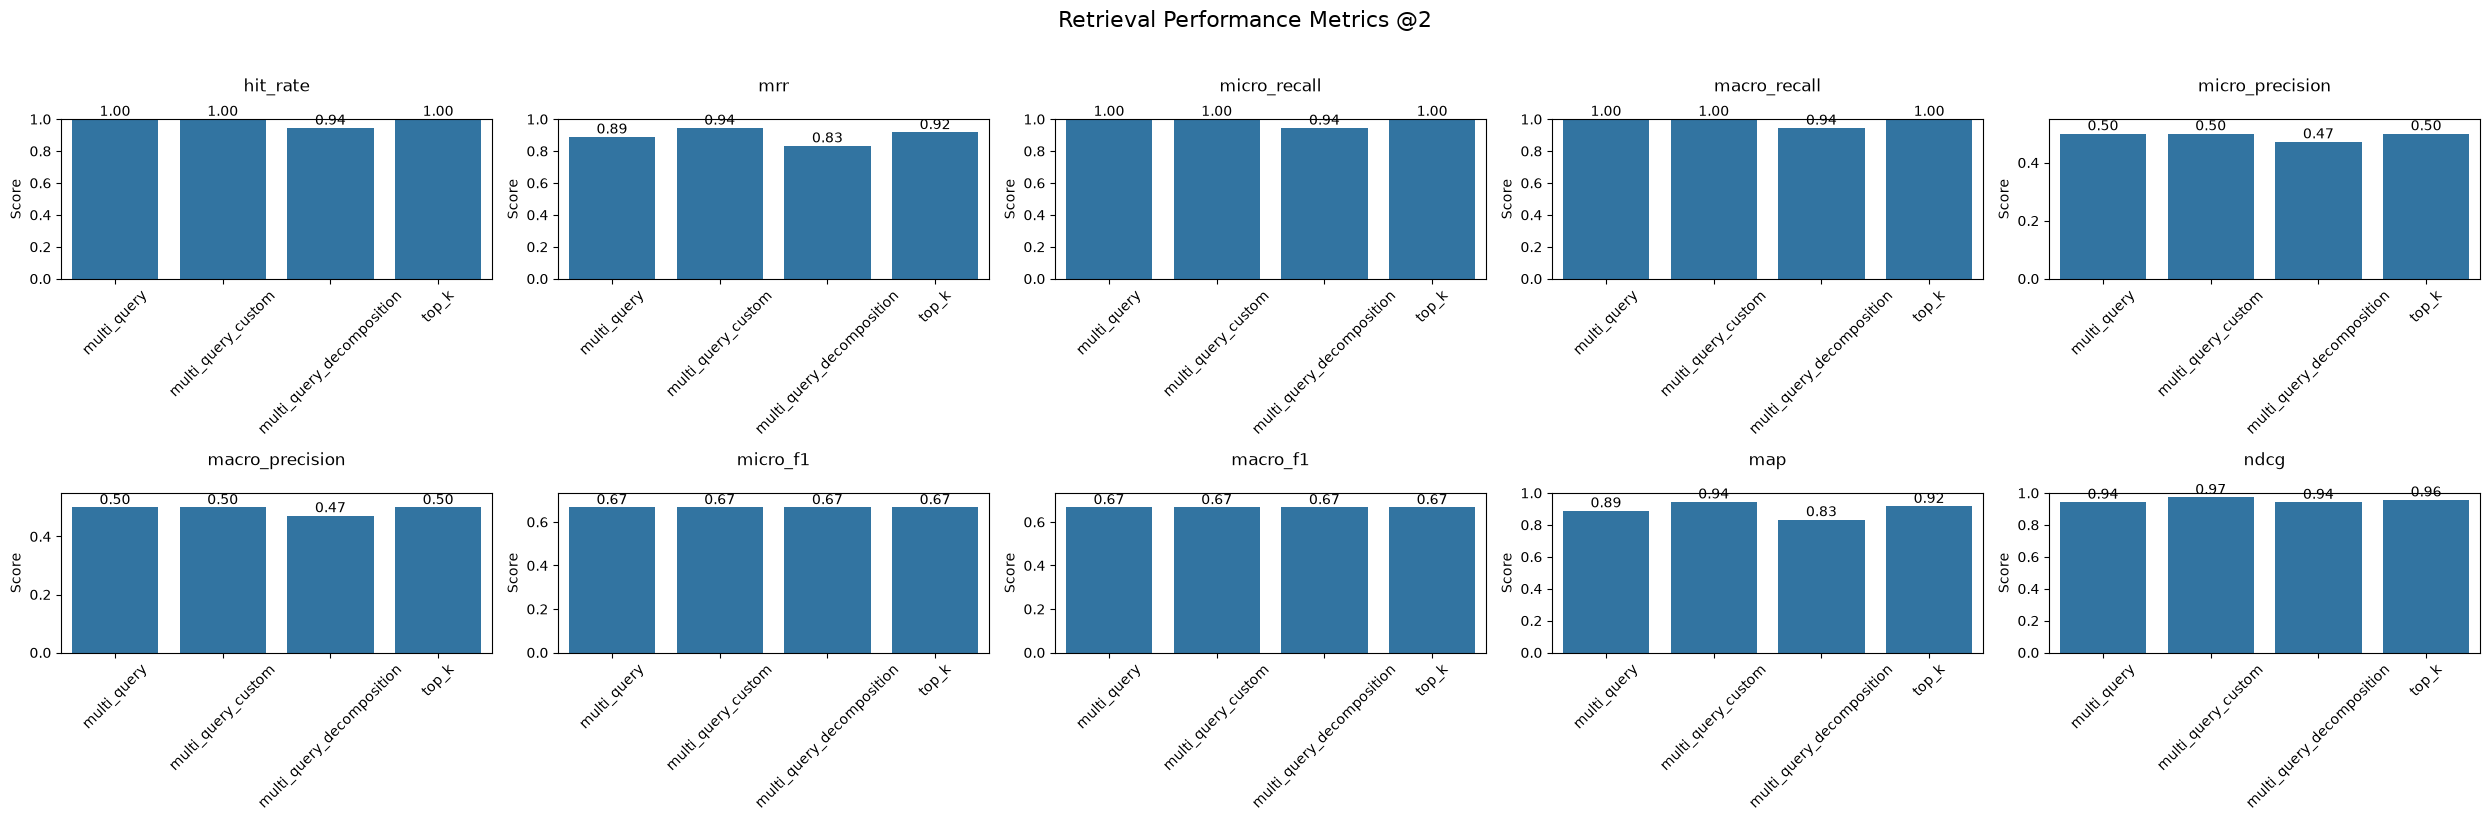

In [37]:
# visualize_retrieval_at_K() 함수의 인수로 평균 평가지표가 저장된 데이터프레임과 리트리버가 꺼내올 문서의 개수를 넘겨서 시각화한다.
visualize_retrieval_at_K(df_mean=df_evaluation_result, k=chroma_k_retriever.search_kwargs['k'],)

# 재순위화(Re-rank) 기법

초기 검색 결과를 다시 순위를 매기는 과정으로 더 정확하고 관련성 높은 결과를 상위로 올리는 것이 목적이다.

<img src="rerank.png" width="1200" align="left" />

In [38]:
chroma_k_retriever.search_kwargs['k'] = 5
chroma_k_retriever.search_kwargs

{'k': 5}

# 재순위화(Re-rank) 기법 - Cross Encoder Reranker

Cross Encoder는 쿼리와 문서 쌍의 관련성을 직접 평가하는 모델로 쿼리와 문서 간의 직접적인 관련성을 평가하여 높은 정확도를 제공한다.

## 작동 원리
① 쿼리와 각 문서를 쌍으로 입력한다.  
② 모델이 이 쌍을 동시에 처리하여 관련성 점수를 출력한다.  
③ 출력된 점수에 따라 문서들을 재정렬 한다.

장점  
&nbsp;&nbsp;&nbsp;▶ 쿼리와 문서를 함께 고려하여 더 정확한 관련성을 평가하기 때문에 높은 정확도가 나온다.  
&nbsp;&nbsp;&nbsp;▶ 쿼리와 문서 간의 복잡한 관계를 포착하여 컨텍스를 이해한다.

Hugging Face의 Cross-Encoder 모델을 사용하여 검색 결과를 재정렬 한다.

Cross Encoder 아키텍처에서는 모델의 입력이 항항 데이터 쌍(두 개의 문장 또는 문서)으로 구성되며, 이들은 Encoder에 의해 공동으로 처리된다.  
Cross Encoder는 검색 쿼리와 검색된 문서 간의 유사성을 계산한다.

https://www.sbert.net/examples/cross_encoder/applications/README.html

<img src="crossEncoderReranker1.png" width="1200" align="left" />

<img src="crossEncoderReranker2.png" width="1200" align="left" />

RAG의 성능을 높이기 위해 단순히 유사도 점수로 문서를 가져오는 것을 넘어, 더 정밀한 모델을 통해 질문과 문서 사이의 연관성을 다시 계산하는 재순위화를 구현한다.

LangChain에서 검색 결과의 관련성을 높이고, LMM에 전달할 토큰을 줄이기 위해 사용하는 재정렬(Reranking) 및 압축(Compressor) 관련 라이브러리들을 import 한다.

`ContextualCompressionRetriever`: 검색기를 감싸서 검색된 문서들을 사용자 질의에 맞게 압축하거나 필터링 한다.  
&nbsp;&nbsp;&nbsp;▶ 1차로 검색된 문서들 중 질의와 관련 없는 내용을 제거하거나, 문서 내에서 직접 관련된 구절만 추출한다.  
&nbsp;&nbsp;&nbsp;▶ 검색 결과의 노이즈를 줄여 LLM 환각(hallucination)을 방지하고 토큰 비용을 절감한다.  
`CrossEncoderReranker`: 검색된 문서 목록을 Cross Encoder 알고리즘을 기반으로 재정렬하여 상위 n개의 문서만 추출한다.  
&nbsp;&nbsp;&nbsp;▶ 사용자 질의와 검색된 각 문서간의 유사도 점수를 Cross Encoder 방식으로 다시 계산한다.  
&nbsp;&nbsp;&nbsp;▶ 계산된 점수를 바탕으로 문서 순위를 재정렬한 후, 설정한 n개만큼의 최상위 문서만 선택해서 반환한다.  
`HuggingFaceCrossEncoder`: Hugging Face에 공개된 Cross Encoder 모델을 파이썬 환경에서 로드하고 실행할 수 있도록 한다.

In [39]:
# 검색된 문서들을 '압축'하거나 '필터링'한다.
from langchain.retrievers import ContextualCompressionRetriever
# 실제로 문서에 순위를 다시 매기는 알고리즘이다.
from langchain.retrievers.document_compressors import CrossEncoderReranker
# Hugging Face의 오픈소스 Cross Encoder 모델을 로드한다.
from langchain_community.cross_encoders import HuggingFaceCrossEncoder

재순위화 모델을 설정한다.

`BAAI/bge-reranker-v2-m3` 모델은 현재 글로벌 검색 및 RAG 시장에서 오픈소스 재순위화 모델 부문에서 사실상 표준이자 가장 높은 점유율을 차지하고 있다.  
베이징 인공지능연구원(BAAI)에서 개발한 다국어 지원 교차 엔코더(Cross-Encoder) 기반 재순위화 모델로 RAG 파이프라인이나 검색 시스템에서 1차로 검색된 후보 문서들을 질문과의 실질적 관련성 기준으로 다시 정렬하여 최종 검색 정밀도를 대폭 끌어올린다.

질문과 문서를 동시에 모델에 넣고 둘 사이의 직접적인 상관관계 점수를 계산해서 일반적인 벡터 유사도 검색보다 훨씬 정확하다.

In [40]:
# HuggingFaceCrossEncoder 클래스의 생성자로 재순위화 모델의 이름을 넘겨서 Hugging Face에서 모델을 다운받는다.
rerank_model = HuggingFaceCrossEncoder(model_name='BAAI/bge-reranker-v2-m3')

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

재순위화 모델을 사용해서 '어떻게 재순위화할 것인가' 정의한다.

In [41]:
# CrossEncoderReranker 클래스의 생성자로 사용할 재순위화 모델과 재순위화를 거쳐 최종적으로 얻어올 문서의 개수를 넘겨서 재순위화 모델을 만든다.
re_ranker = CrossEncoderReranker(
    model=rerank_model, # 재순위화 모델을 지정한다.
    top_n=3 # 재순위화를 거쳐 최종적으로 얻어올 문서의 개수를 지정한다.
)

재순위화 모델을 이용한 검색기를 구성한다.

In [42]:
# ContextualCompressionRetriever 클래스의 생성자로 기본 검색기와 재순위화 모델을 넘겨서 맥락 압축 검색기를 만든다.
cross_encoder_reranker_retriever = ContextualCompressionRetriever(
    # 1단계(기본) 검색기를 지정한다. Chroma 벡터검색기에서 질문과 비슷한 문서를 대량으로 가져온다.
    base_retriever=chroma_k_retriever,
    # 2단계 검색기(재순위화 모델)를 지정한다. 1단계(기본) 검색기에서 가져온 문서들을 재순위화 모델로 다시 순위를 매긴다.
    base_compressor=re_ranker
)

검색기를 실행한다.

In [43]:
query = '테슬라의 회장은 누구인가요?'
# invoke() 메소드가 실행되면 질문이 ContextualCompressionRetriever의 base_retriever에 지정된 chroma_k_retriever로 전달되서 유사도 점수가 높은 순으로 5개의
# 문서를 ContextualCompressionRetriever의 base_compressor에 지정된 re_ranker에 전달되어 재순위화를 해서 재순위 점수가 높은 순으로 3개의 문서를 얻어온다.
retriever_docs = cross_encoder_reranker_retriever.invoke(query)

<img src="langSmith12.png" width="1200" align="left" />

In [44]:
print(f'쿼리: {query}')
print('검색 결과')
for doc in retriever_docs:
    print(doc.page_content)
    print(doc.metadata)
    print('-' * 100)

쿼리: 테슬라의 회장은 누구인가요?
검색 결과
테슬라(Tesla, Inc
)는 텍사스주 오스틴에 본사를 둔 미국의 대표적인 전기차 제조업체입니다
2003년 마틴 에버하드(CEO)와 마크 타페닝(CFO)에 의해 설립된 테슬라는 2004년 페이팔과 Zip2의 공동 창업자인 일론 머스크의 참여로 큰 전환점을 맞았습니다

(참고: 이 문서는 테슬라에 대한 정보를 담고 있습니다.)
{'doc_id': 3, 'source': './data\\테슬라_KR.txt'}
----------------------------------------------------------------------------------------------------
머스크는 최대 주주이자 회장으로서 회사를 현재의 성공으로 이끌었습니다
회사 이름은 유명한 물리학자이자 전기공학자인 니콜라 테슬라의 이름을 따서 지어졌습니다
테슬라는 2010년 6월 나스닥에 상장되었습니다
2023년 테슬라는 1,808,581대의 차량을 판매하여 2022년에 비해 37
65% 증가했습니다

(참고: 이 문서는 테슬라에 대한 정보를 담고 있습니다.)
{'doc_id': 4, 'source': './data\\테슬라_KR.txt'}
----------------------------------------------------------------------------------------------------
리비안은 MIT 박사 출신 RJ 스카린지가 2009년에 설립한 혁신적인 미국 전기차 제조업체입니다
2011년부터 자율 전기차에 집중한 리비안은 2015년 대규모 투자를 통해 크게 성장하며 미시간과 베이 지역에 연구소를 설립했습니다
주요 공급업체와의 접근성을 높이기 위해 본사를 미시간주 리보니아로 이전했습니다

(참고: 이 문서는 리비안에 대한 정보를 담고 있습니다.)
{'source': './data\\리비안_KR.txt', 'doc_id': 0}
---------------------------------------

# 재순위화(Re-rank) 기법 - LLM Reranker

LLM을 사용한 재순위화는 모델의 풍부한 지식과 추론 능력을 활용하여 검색 결과를 개선해서 더 넓은 맥락과 복잡한 관계를 이해할 수 있어, 특히 추론이 필요한 상활일 경우 유용하게 사용된다.

작동 원리  
① 초기 검색 결과를 LLM에 입력으로 제공한다.  
② LLM이 각 문서의 관련성을 평가하고 순위를 조정한다.  
③ 조정된 순위에 따라 문서를 재정렬 한다.

장점  
&nbsp;&nbsp;&nbsp;▶ LLM의 깊은 언어 이해 능력을 활용할 수 있다.  
&nbsp;&nbsp;&nbsp;▶ 다양한 기준으로 유연성 있는 재순위화가 가능하다.  
&nbsp;&nbsp;&nbsp;▶ LLM이 순위를 조정한 이유를 설명할 수 있다.

LLM을 사용하여 초기 검색된 문서 중에서 쿼리와 관련된 정도에 따라 순서를 조정한다.

LLM의 추론 능력을 직접 활용하여 여러 문서를 한꺼번에 LLM 모델에게 넘기고 질문에 가장 적합한 순서대로 나열하기 위해 LLMListwiseRerank 라이브러리를 import 한다.

In [45]:
from langchain.retrievers.document_compressors import LLMListwiseRerank

재순위화 모델을 설정한다.

In [46]:
# 재순위화를 위해서 모델의 답변이 일관되도록 '창의성'을 배제하고 일관된 답변을 할게끔 temperature를 0으로 설정한다.
llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)

재순위화 모델을 사용해서 '어떻게 재순위화할 것인가' 정의한다.

In [47]:
# from_llm() 메소드로 사용할 재순위화 모델과 재순위화를 거쳐 최종적으로 얻어올 문서의 개수를 넘겨서 재순위화 모델을 만든다.
# 내부적으로 LLM에게 '다음 문서들 중 질문에 가장 적합한 것들을 골라줘'라는 특수한 프롬프트를 보낸다.
re_ranker = LLMListwiseRerank.from_llm(
    llm=llm, # 재순위화 모델을 지정한다.
    top_n=3
)

재순위화 모델을 이용한 검색기를 구성한다.

In [48]:
llm_reranker_retriever = ContextualCompressionRetriever(
    base_retriever=chroma_k_retriever,
    base_compressor=re_ranker
)

검색기를 실행한다.

In [49]:
query = '테슬라의 회장은 누구인가요?'
retriever_docs = llm_reranker_retriever.invoke(query)

<img src="langSmith13.png" width="1200" align="left" />

In [50]:
print(f'쿼리: {query}')
print('검색 결과')
for doc in retriever_docs:
    print(doc.page_content)
    print(doc.metadata)
    print('-' * 100)

쿼리: 테슬라의 회장은 누구인가요?
검색 결과
머스크는 최대 주주이자 회장으로서 회사를 현재의 성공으로 이끌었습니다
회사 이름은 유명한 물리학자이자 전기공학자인 니콜라 테슬라의 이름을 따서 지어졌습니다
테슬라는 2010년 6월 나스닥에 상장되었습니다
2023년 테슬라는 1,808,581대의 차량을 판매하여 2022년에 비해 37
65% 증가했습니다

(참고: 이 문서는 테슬라에 대한 정보를 담고 있습니다.)
{'source': './data\\테슬라_KR.txt', 'doc_id': 4}
----------------------------------------------------------------------------------------------------
테슬라(Tesla, Inc
)는 텍사스주 오스틴에 본사를 둔 미국의 대표적인 전기차 제조업체입니다
2003년 마틴 에버하드(CEO)와 마크 타페닝(CFO)에 의해 설립된 테슬라는 2004년 페이팔과 Zip2의 공동 창업자인 일론 머스크의 참여로 큰 전환점을 맞았습니다

(참고: 이 문서는 테슬라에 대한 정보를 담고 있습니다.)
{'source': './data\\테슬라_KR.txt', 'doc_id': 3}
----------------------------------------------------------------------------------------------------
2012년부터 2023년 3분기까지 테슬라의 전 세계 누적 판매량은 4,962,975대를 초과했습니다
SMT Packaging에 따르면, 2023년 테슬라의 판매량은 전 세계 전기차 시장의 약 12
9%를 차지했습니다

(참고: 이 문서는 테슬라에 대한 정보를 담고 있습니다.)
{'source': './data\\테슬라_KR.txt', 'doc_id': 5}
------------------------------------------------------------------------------------------

# 맥락 압축(Contextual Compression)

검색된 문서를 쿼리의 맥락에 맞게 압축하거나 필터링하는 기법으로 긴 문서에서 핵심 정보만을 효과적으로 활용할 수 있고 LLM에 전달되는 정보의 양을 줄이고, 관련성 높은 정보만을 제공하여 성능을 개선한다.  
초기 문서의 검색을 수행하는 기본 검색기와 검색된 문서를 쿼리에 맞게 압축 또는 필터링하는 문서 압축기로 구성된다.

쿼리와 직접적으로 관련된 정보만을 제공하여 관련성을 향상하고 LLM에 전달되는 데이터량을 줄여 처리 속도를 높이고 비용을 절감할 수 있으며 불필요한 정보를 제거하여 더 정확하고 집중된 응답을 생성할 수 있다.

# 맥락 압축(Contextual Compression) - LLMChainFilter

LLM을 사용하여 검색된 문서 중 관련성 높은 문서만을 선택한다.  
LLM을 사용하여 초기 검색된 문서 중 어떤 것을 필터링하고 어떤 것을 반환할 지 결정한다.  
문서 내용을 압축하거나 변경하지 않는다. 문서 내용은 그대로 유지한다.

앞의 리랭커들이 `순서`를 바꾸는 것에 집중했다면 LLMChainFilter는 질문과 상관없는 문서를 아예 `삭제`하여 꼭 필요한 정보만 남기는 역할을 한다.

LLM을 사용하여 검색된 각 문서가 질문과 관련이 있는지 Yes/No로 판단해서 관련 없는 문서는 최종 결과에서 제외하기 위해 LLMChainFilter를 import 한다.

In [51]:
from langchain.retrievers.document_compressors import LLMChainFilter

필터링 모델을 사용해서 '어떻게 필터링할 것인가' 정의한다.

In [52]:
# llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)
# from_llm() 메소드로 사용할 필터링에 사용할 LLM 모델을 넘겨서 필터링 모델을 만든다.
# 내부적으로 LLM에게 '다음 문서들 중 질문과 관련이 없는 문서를 제외시켜줘'라는 특수한 프롬프트를 보낸다.
context_filter = LLMChainFilter.from_llm(llm=llm)

필터링 모델을 이용한 검색기를 구성한다.

In [53]:
llm_filter_compression_retriever = ContextualCompressionRetriever(
    # 벡터검색기에서 유사도 기반으로 문서를 가져오는 1차 필터링을 실행한다.
    base_retriever=chroma_k_retriever,
    # 1차 필터링 결과를 context_filter에 넣어주면 LLM이 각 문서를 읽고 질문과 무관하면 버리고, 유용한 것만 2차 필터링을 실행한다.
    base_compressor=context_filter
)

검색기를 실행한다.

In [54]:
query = '테슬라의 회장은 누구인가요?'
retriever_docs = llm_filter_compression_retriever.invoke(query)

<img src="langSmith14.png" width="1200" align="left" />

In [55]:
print(f'쿼리: {query}')
print('검색 결과')
for doc in retriever_docs:
    print(doc.page_content)
    print(doc.metadata)
    print('-' * 100)

쿼리: 테슬라의 회장은 누구인가요?
검색 결과
테슬라(Tesla, Inc
)는 텍사스주 오스틴에 본사를 둔 미국의 대표적인 전기차 제조업체입니다
2003년 마틴 에버하드(CEO)와 마크 타페닝(CFO)에 의해 설립된 테슬라는 2004년 페이팔과 Zip2의 공동 창업자인 일론 머스크의 참여로 큰 전환점을 맞았습니다

(참고: 이 문서는 테슬라에 대한 정보를 담고 있습니다.)
{'doc_id': 3, 'source': './data\\테슬라_KR.txt'}
----------------------------------------------------------------------------------------------------
머스크는 최대 주주이자 회장으로서 회사를 현재의 성공으로 이끌었습니다
회사 이름은 유명한 물리학자이자 전기공학자인 니콜라 테슬라의 이름을 따서 지어졌습니다
테슬라는 2010년 6월 나스닥에 상장되었습니다
2023년 테슬라는 1,808,581대의 차량을 판매하여 2022년에 비해 37
65% 증가했습니다

(참고: 이 문서는 테슬라에 대한 정보를 담고 있습니다.)
{'source': './data\\테슬라_KR.txt', 'doc_id': 4}
----------------------------------------------------------------------------------------------------


# 맥락 압축(Contextual Compression) - LLMChainExtractor

검색된 문서들을 순회하며 각 문서를 LLM의 입력으로 제공하고 LLM은 쿼리와 관련된 내용만 추출해서 요약한다.

LLM을 사용하여 검색된 각 문서가 질문에 대한 답이 될 만한 문장이나 단락을 추출하는 압축기를 사용하기 위해 LLMChainExtractor를 import 한다.

In [56]:
from langchain.retrievers.document_compressors import LLMChainExtractor

필터링 모델을 사용해서 '어떻게 요약할 것인가' 정의한다.

In [57]:
# llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)
# from_llm() 메소드로 사용할 관련된 내용만 추출해서 요약에 사용할 LLM 모델을 넘겨서 요약 모델을 만든다.
# 내부적으로 LLM에게 '다음 문서들을 질문에 관련된 내용만 추출해줘'라는 특수한 프롬프트를 보낸다.
compressor = LLMChainExtractor.from_llm(llm=llm)

질문과 관련된 내용을 요약하는 모델을 이용한 검색기를 구성한다.

In [58]:
llm_filter_compression_retriever = ContextualCompressionRetriever(
    # 벡터검색기에서 유사도 기반으로 문서를 가져온다.
    base_retriever=chroma_k_retriever,
    # 벡터검색기에서 가져온 결과를 compressor에 넣어주면 LLM이 각 문서를 읽고 질문과 관련된 내용만 추출해서 요약한다.
    base_compressor=compressor
)

검색기를 실행한다.

In [59]:
query = '테슬라의 회장은 누구인가요?'
retriever_docs = llm_filter_compression_retriever.invoke(query)

<img src="langSmith15.png" width="1200" align="left" />

In [60]:
print(f'쿼리: {query}')
print('검색 결과')
for doc in retriever_docs:
    print(doc.page_content)
    print(doc.metadata)
    print('-' * 100)

쿼리: 테슬라의 회장은 누구인가요?
검색 결과
일론 머스크의 참여로 큰 전환점을 맞았습니다
{'source': './data\\테슬라_KR.txt', 'doc_id': 3}
----------------------------------------------------------------------------------------------------
머스크는 최대 주주이자 회장으로서 회사를 현재의 성공으로 이끌었습니다
{'source': './data\\테슬라_KR.txt', 'doc_id': 4}
----------------------------------------------------------------------------------------------------


# 맥락 압축(Contextual Compression) - EmbeddingsFilter

LLM을 사용하지 않는 방식으로 문서를 쿼리를 임베딩 쿼리와 충분히 유사한 임베딩을 가진 문서만 반환한다.  
쿼리와 문서를 벡터로 임베딩 후 쿼리 벡터와 문서 벡터 간의 유사도를 계산해서 유사도가 임계값을 넘는 문서만 반환한다.
이 방식은 LLM을 직접 호출하지 않기 때문에 속도가 훨씬 빠르고 비용이 저렴하다는 장점이 있다.

LLM 대신 임베딩 모델의 유사도를 활용하여 관련 없는 문서를 걸러내기 위해서 EmbeddingsFilter를 import 한다.

In [61]:
from langchain.retrievers.document_compressors import EmbeddingsFilter

임베딩 모델을 사용해서 '쿼리 벡터와 문서 벡터 간의 유사도의 임계값을 계산하는' 검색기 모델을 선언한다.

In [62]:
# embeddings_model = HuggingFaceEmbeddings(model_name='BAAI/bge-m3')
# EmbeddingsFilter 클래스의 생성자로 1차 검색기로 사용할 벡터저장소를 생성할 때 사용한 임베딩 모델과 임계값을 넘겨서 객체를 생성한다.
embeddings_filter = EmbeddingsFilter(
    # 벡터저장소를 생성할 때 텍스트를 숫자로 변환한 임베딩 모델을 지정한다.
    embeddings=embeddings_model,
    # 필터링의 기준점이 되는 유사도를 지정한다. 이 수치를 높이면 매우 정확한 문서만 남고, 낮추면 더 많은 문서를 포함하게 된다.
    similarity_threshold=0.5
)

질문과 관련된 문서를 임베딩해서 지정한 임계값 이상인 문서를 얻어오는 구성한다.

In [63]:
embed_filter_compression_retriever = ContextualCompressionRetriever(
    # 기본 벡터검색기로 얻어온 문서를 재순위화 하는 리랭커 모델을 기본 검색기로 지정한다.
    base_retriever=cross_encoder_reranker_retriever,
    # 리랭커 모델에서 가져온 결과를 embeddings_filter에 쿼리 벡터와 문서 벡터 간의 유사도를 계산해서 임계값을 넘는 문서를 반환하는 모델을 지정한다.
    base_compressor=embeddings_filter
)

검색기를 실행한다.

In [64]:
query = '테슬라의 회장은 누구인가요?'
retriever_docs = embed_filter_compression_retriever.invoke(query)

<img src="langSmith16.png" width="1200" align="left" />

In [65]:
print(f'쿼리: {query}')
print('검색 결과')
for doc in retriever_docs:
    print(doc.page_content)
    print(doc.metadata)
    print('-' * 100)

쿼리: 테슬라의 회장은 누구인가요?
검색 결과
테슬라(Tesla, Inc
)는 텍사스주 오스틴에 본사를 둔 미국의 대표적인 전기차 제조업체입니다
2003년 마틴 에버하드(CEO)와 마크 타페닝(CFO)에 의해 설립된 테슬라는 2004년 페이팔과 Zip2의 공동 창업자인 일론 머스크의 참여로 큰 전환점을 맞았습니다

(참고: 이 문서는 테슬라에 대한 정보를 담고 있습니다.)
{'doc_id': 3, 'source': './data\\테슬라_KR.txt'}
----------------------------------------------------------------------------------------------------
머스크는 최대 주주이자 회장으로서 회사를 현재의 성공으로 이끌었습니다
회사 이름은 유명한 물리학자이자 전기공학자인 니콜라 테슬라의 이름을 따서 지어졌습니다
테슬라는 2010년 6월 나스닥에 상장되었습니다
2023년 테슬라는 1,808,581대의 차량을 판매하여 2022년에 비해 37
65% 증가했습니다

(참고: 이 문서는 테슬라에 대한 정보를 담고 있습니다.)
{'source': './data\\테슬라_KR.txt', 'doc_id': 4}
----------------------------------------------------------------------------------------------------


# 맥락 압축(Contextual Compression) - DocumentCompressorPipeline

DocumentCompressorPipeline을 사용하면 여러 압축 기법을 순차적으로 적용할 수 있고 EmbeddingsRedundantFilter를 추가해서, 문서를 더 작은 조각으로 나누거나 중복 문서를 제거하는 작업도 가능하다.

여러 압축기를 순차적으로 결합하는 방식으로 각 압축기의 출력이 다음 압축기의 입력으로 전달된다.

<img src="DocumentCompressorPipeline.png" width="1200" align="left" />

여러 개의 압축기를 순서대로 실행할 수 있게 하기위해 DocumentCompressorPipeline을 import 한다.

In [66]:
from langchain.retrievers.document_compressors import DocumentCompressorPipeline

검색된 문서들 중 같은 정보를 담은 문서를 LLM에게 보내면 낭비되므로 내용이 서로 너무 비슷한 중복 문서를 제거하기 위해 EmbeddingsRedundantFilter를 import 한다.

In [67]:
from langchain_community.document_transformers import EmbeddingsRedundantFilter

파이프라인에 사용하기 위한 중복 제거 필터 도구를 설정한다.

In [68]:
# embeddings_model = HuggingFaceEmbeddings(model_name='BAAI/bge-m3')
# EmbeddingsRedundantFilter 클래스의 생성자로 벡터저장소를 만들 때 사용한 임베딩 모델을 넘겨서 중복 제거 필터 도구를 설정한다.
redundant_filter = EmbeddingsRedundantFilter(embeddings=embeddings_model)

파이프라인에 사용하기 위한 중복이 제거된 문서들 중 질문과 유사도가 0.5 미만인 문서를 제거하는 도구를 설정한다.

In [69]:
embeddings_filter = EmbeddingsFilter(embeddings=embeddings_model, similarity_threshold=0.5)

파이프라인에 사용하기 위한 결과를 재정렬하는 도구를 설정한다.

In [70]:
# llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)
re_ranker = LLMListwiseRerank.from_llm(llm=llm, top_n=3)

위에서 만든 세 가지 도구를 순서대로 파이프라인을 만든다.

In [71]:
# DocumentCompressorPipeline 클래스의 생성자로 순서대로 실행할 도구들을 넘겨서 파이프라인을 만든다.
pipeline_compressors = DocumentCompressorPipeline(
    # 위에서 만든 세 가지 도구를 실행할 순서대로 리스트로 묶어서 배치한다. 중복 제거 => 유사도 필터링 => 재정렬 순서로 실행된다.
    transformers=[redundant_filter, embeddings_filter, re_ranker]
)

위에서 만든 '파이프라인을 실행'하는 검색기 모델을 선언한다.

In [72]:
pipeline_compression_retriever = ContextualCompressionRetriever(
    base_retriever=chroma_k_retriever,
    # 위에서 DocumentCompressorPipeline 객체를 사용해서 조립한 압축기를 지정한다.
    base_compressor=pipeline_compressors
)

검색기를 실행한다.

In [73]:
query = '테슬라의 회장은 누구인가요?'
retriever_docs = pipeline_compression_retriever.invoke(query)

<img src="langSmith17.png" width="1200" align="left" />

In [74]:
print(f'쿼리: {query}')
print('검색 결과')
for doc in retriever_docs:
    print(doc.page_content)
    print(doc.metadata)
    print('-' * 100)

쿼리: 테슬라의 회장은 누구인가요?
검색 결과
머스크는 최대 주주이자 회장으로서 회사를 현재의 성공으로 이끌었습니다
회사 이름은 유명한 물리학자이자 전기공학자인 니콜라 테슬라의 이름을 따서 지어졌습니다
테슬라는 2010년 6월 나스닥에 상장되었습니다
2023년 테슬라는 1,808,581대의 차량을 판매하여 2022년에 비해 37
65% 증가했습니다

(참고: 이 문서는 테슬라에 대한 정보를 담고 있습니다.)
{'doc_id': 4, 'source': './data\\테슬라_KR.txt'}
----------------------------------------------------------------------------------------------------
테슬라(Tesla, Inc
)는 텍사스주 오스틴에 본사를 둔 미국의 대표적인 전기차 제조업체입니다
2003년 마틴 에버하드(CEO)와 마크 타페닝(CFO)에 의해 설립된 테슬라는 2004년 페이팔과 Zip2의 공동 창업자인 일론 머스크의 참여로 큰 전환점을 맞았습니다

(참고: 이 문서는 테슬라에 대한 정보를 담고 있습니다.)
{'doc_id': 3, 'source': './data\\테슬라_KR.txt'}
----------------------------------------------------------------------------------------------------
2012년부터 2023년 3분기까지 테슬라의 전 세계 누적 판매량은 4,962,975대를 초과했습니다
SMT Packaging에 따르면, 2023년 테슬라의 판매량은 전 세계 전기차 시장의 약 12
9%를 차지했습니다

(참고: 이 문서는 테슬라에 대한 정보를 담고 있습니다.)
{'doc_id': 5, 'source': './data\\테슬라_KR.txt'}
------------------------------------------------------------------------------------------

## DocumentCompressorPipeline를 RAG 파이프라인으로 적용하기

context(문맥, 사전정보)를 LLM에게 넘기지 않고 질문에 대한 답변을 얻어온다.

In [75]:
# from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model='gpt-4o-mini', temperature=0.7)

query = '테슬라의 회장은 누구인가요?'
llm.invoke(query)

AIMessage(content='테슬라의 회장은 일론 머스크(Elon Musk)입니다. 그는 테슬라의 CEO이기도 하며, 회사의 비전과 전략을 이끌고 있습니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 40, 'prompt_tokens': 17, 'total_tokens': 57, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_955bdc7ddd', 'id': 'chatcmpl-EQTiiUhe6Y5vDXy9IhYj3MduH329A', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--01a0c317-50a0-70e2-bd3f-398a79c6da7c-0', usage_metadata={'input_tokens': 17, 'output_tokens': 40, 'total_tokens': 57, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

LCEL(LangChain Expression Language) 방식을 사용해서 context를 LLM에게 넘기고 질문에 대한 답변을 얻어온다.

In [76]:
# from langchain_core.prompts import ChatPromptTemplate
# from langchain_core.output_parsers import StrOutputParser
# 입력을 그대로 가공 없이 다음 단계로 전달한다. 여기서는 질문을 가공 없이 그대로 프롬프트에 넘기기 위해서 사용한다.
from langchain_core.runnables import RunnablePassthrough

프롬프트 템플릿을 설정한다.

In [77]:
# LLM 모델에서 줄 지시 사항(페르소나, 규칙, 환각 방지, 변수 등)을 프롬프트로 정의한다.
template = '''
당신은 유능한 나만의 인공지능 비서입니다.
당신이 수행할 과제는 제공된 문맥(context)을 바탕으로 다음 질문에 답변하는 것입니다.
다음 문맥(context)에만 근거하여 질문에 답변하고 외부 정보나 지식은 절대로 사용하지 마세요.
만약 문맥(context)이 질문과 관련이 없다면, '답변에 필요한 근거를 찾지 못했습니다.'라고 답변하세요.

[문맥(context)]
{context}

[질문]
{question}

[답변]
'''

prompt = ChatPromptTemplate.from_template(template=template)
prompt

ChatPromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template="\n당신은 유능한 나만의 인공지능 비서입니다.\n당신이 수행할 과제는 제공된 문맥(context)을 바탕으로 다음 질문에 답변하는 것입니다.\n다음 문맥(context)에만 근거하여 질문에 답변하고 외부 정보나 지식은 절대로 사용하지 마세요.\n만약 문맥(context)이 질문과 관련이 없다면, '답변에 필요한 근거를 찾지 못했습니다.'라고 답변하세요.\n\n[문맥(context)]\n{context}\n\n[질문]\n{question}\n\n[답변]\n"), additional_kwargs={})])

context를 지정하기 위해서 검색기가 찾아온 여러 개의 문서(Document 객체)에서 본문(page_content)만 꺼내서 하나의 긴 문자열로 만들어서 리턴하는 함수를 선언한다.

In [78]:
def format_docs(docs):
    return '\n\n'.join([doc.page_content for doc in docs])

LCEL를 사용해서 RAG chain을 구성한다.

In [79]:
# |(파이프 연산자)를 사용해서 | 앞의 출력 결과를 | 뒤의 객체로 데이터를 순차적으로 전달한다.
rag_chain = (
    # 프롬프트를 완성하기 위해서 변수({context}, {question})를 채워야 한다.
    # {context}에는 pipeline_compression_retriever의 실행 결과를 format_docs 함수를 이용해서 하나의 긴 문자열로 만들어서 전달한다.
    # {question}에는 rag_chain을 실행할 때 넣어주는 질문을 그대로 전달한다.
    {'context': pipeline_compression_retriever | format_docs,'question': RunnablePassthrough()}
    # 준비된 prompt template의 변수에 위의 딕셔너리로 전달되는 내용을 채워넣어 프롬프트를 완성한다.
    | prompt 
    # 완성된 프롬프트 LLM 모델에 전달해서 답변을 생성한다.
    | llm 
    # LLM이 생성한 답변에서 텍스트만 추출한다.
    | StrOutputParser()
)

RAG chain을 실행한다.

<img src="langSmith18.png" width="1200" align="left" />

In [80]:
rag_chain.invoke('테슬라 회장은 누구인가요?')

'일론 머스크가 테슬라의 회장입니다.'

In [81]:
rag_chain.invoke('리비안은 2011년에 어떤 차를 공개했나요')

'리비안은 2011년에 프로토타입 해치백을 공개했습니다.'